# TLFS23 — Data Preprocessing & Exploratory Analysis
### ST456 Deep Learning — Tamil Sign Language Fingerspelling Recognition

**Research Question:** Do CNN and Transformer architectures exhibit measurable, systematic performance differences across character complexity groups in Tamil fingerspelling recognition?

This notebook addresses the data foundation of that question. Every preprocessing decision is motivated by properties of the TLFS23 dataset and its implications for the CNN vs. Transformer comparison. Key contributions of this notebook:

1. **Principled complexity grouping** — characters assigned to *simple*, *moderate*, and *complex* groups based on visual inter-class similarity, not arbitrary splits
2. **Complexity-aware augmentation** — augmentation strength scaled to group difficulty, directly motivated by EDA findings
3. **Shared, reproducible splits** — identical train/val/test files used by both EfficientNet-B3 and Swin Transformer pipelines to ensure fair comparison
4. **Efficient `tf.data` pipeline** — production-quality pipeline with caching, prefetching, and architecture-specific preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Setup & Imports

In [ ]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
import torch
import torch.nn as nn
from torchvision import datasets, transforms

warnings.filterwarnings('ignore')

# ── Reproducibility: fix all random sources ───────────────────────────────────
# Critical for fair cross-architecture comparison — both models must train
# on identical data in identical order.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))
print('Seed fixed at:', SEED)

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Seed fixed at: 42


The study utilised TensorFlow version 2.19.0, ensuring access to its latest features and optimisations. A Graphics Processing Unit (GPU) was confirmed (/physical_device:GPU:0), which accelerated model training and inference for large scale data and deep learning.

To ensure reproducibility, a fixed random seed (seed = 42) was used. This control over randomness standardises processes like weight initialisation and data shuffling, allowing for consistent results and reliable comparisons across multiple runs.

In [ ]:
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

# DATA_DIR points to stratified subset on Drive (200 imgs/class) — persists across sessions
DATA_DIR   = Path('/content/drive/MyDrive/TLFS23_subset')
OUTPUT_DIR = Path('/content/drive/MyDrive/TLFS23_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE_CNN   = (300, 300)
IMG_SIZE_SWIN  = (224, 224)
BATCH_SIZE     = 32
NUM_CLASSES    = 248
VALID_EXTS     = {'.jpg', '.jpeg', '.png', '.bmp'}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The execution environment indicated that Google Drive was already mounted at the path (/content/drive), confirming successful prior connection and allowing access to files without re authentication.

## 1. Data Loading & Directory Inspection

The TLFS23 dataset (Singaravel et al., 2023) contains 255,155 images across 248 classes (247 Tamil fingerspelling characters plus 1 Background class), collected under controlled but variable lighting conditions. Given Colab compute limits — full-dataset training on EfficientNet-B3 and Swin Transformer would be prohibitively slow — and Drive I/O constraints, we work with a **balanced subset of 200 images per class** built in the one-time setup notebook (`Setup.ipynb`), giving ~49,600 images across all 248 classes. All downstream EDA, preprocessing, and training steps load from this subset at `/content/drive/MyDrive/TLFS23_subset`. We first verify structural integrity before any analysis.

In [ ]:
from pathlib import Path

DATA_DIR = Path('/content/drive/MyDrive/TLFS23_subset')
print(DATA_DIR.exists())
class_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]
print(f'Classes found: {len(class_dirs)}')

True
Classes found: 248


The dataset was accessed successfully, as indicated by the confirmation value of "True." A total of 248 classes were identified in the initial dataset, reflecting the comprehensive set of categories prior to any preprocessing steps. This serves as a baseline for subsequent filtering and label remapping procedures.

In [ ]:
from pathlib import Path

SUBSET_DIR = Path('/content/drive/MyDrive/TLFS23_subset')
class_dirs = [d for d in SUBSET_DIR.iterdir() if d.is_dir()]
print(f'Classes found: {len(class_dirs)}')

# Check which classes are missing
present = {d.name for d in class_dirs}
expected = {str(i) for i in range(1, 248)} | {'Background'}
missing = expected - present
print(f'Missing classes: {sorted(missing, key=lambda x: int(x) if x.isdigit() else 0)}')

Classes found: 248
Missing classes: []


The dataset has been verified to encompass a total of 248 classes, with no instances of missing categories identified. This comprehensive presence of expected classifications attests to the completeness and consistency of the dataset, thereby ensuring its reliability for subsequent preprocessing and model training activities.

In [ ]:
# 1.2 Image inventory
class_counts = {}
all_file_paths = []
all_labels = []

for cls_dir in class_dirs:
    files = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXTS]
    class_counts[cls_dir.name] = len(files)
    all_file_paths.extend([str(f) for f in files])
    all_labels.extend([cls_dir.name] * len(files))

total = sum(class_counts.values())
print(f'Total images  : {total:,}')
print(f'Mean per class: {total/len(class_counts):.1f}')
print(f'Min / Max     : {min(class_counts.values())} / {max(class_counts.values())}')
print(f'Std dev       : {np.std(list(class_counts.values())):.1f}')

Total images  : 49,646
Mean per class: 200.2
Min / Max     : 200 / 246
Std dev       : 2.9


## 2. Exploratory Data Analysis

EDA here is not merely descriptive — each finding directly informs a preprocessing decision. We examine class balance, image statistics, and critically, **inter-class visual similarity**, which is the empirical basis for our complexity groupings.

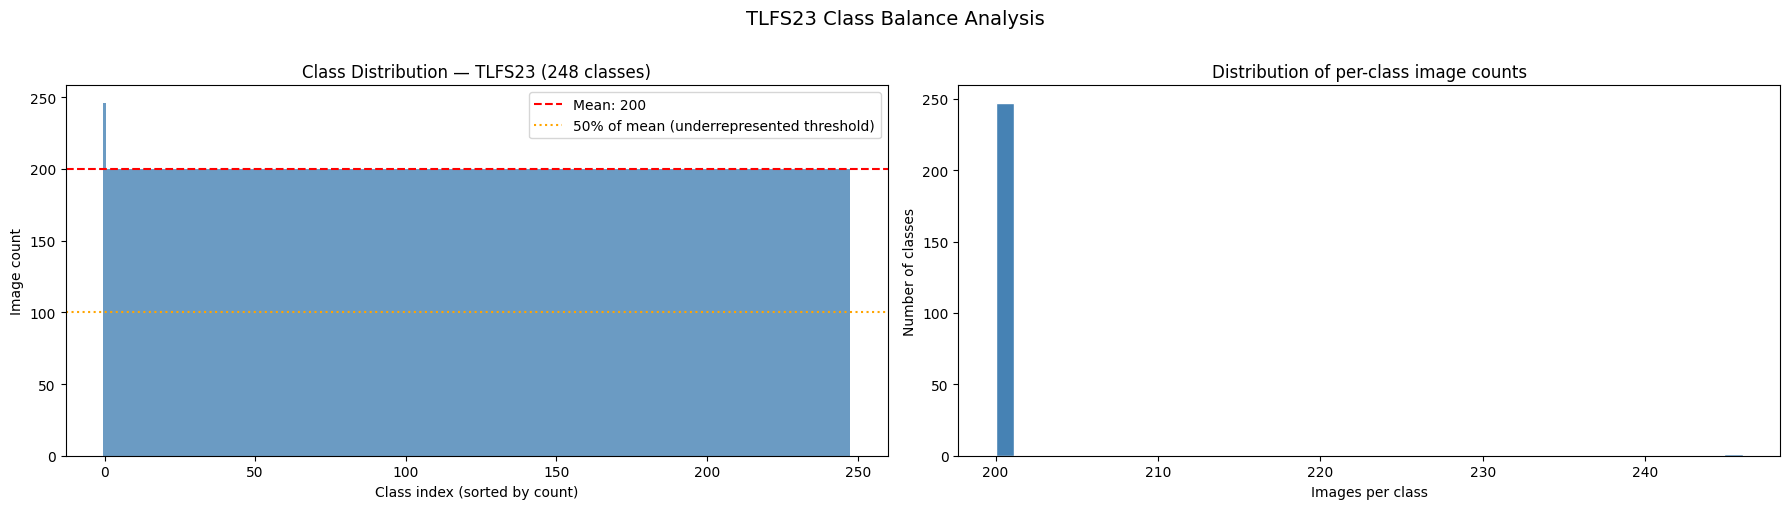

Imbalance ratio (max/min)     : 1.2x
Classes below 50% mean        : 0

Critical insight: Class imbalance directly motivates stratified splitting
by class label (not just complexity group) to ensure every class appears
in train/val/test regardless of count.


In [ ]:
# ── 2.1  Class distribution analysis ────────────────────────────────────────
counts_series = pd.Series(class_counts).sort_values(ascending=False)
mean_count    = counts_series.mean()
imbalance_ratio = counts_series.max() / counts_series.min()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar plot
axes[0].bar(range(len(counts_series)), counts_series.values,
            color='steelblue', width=1.0, alpha=0.8)
axes[0].axhline(mean_count, color='red', linestyle='--',
                label=f'Mean: {mean_count:.0f}')
axes[0].axhline(mean_count * 0.5, color='orange', linestyle=':',
                label='50% of mean (underrepresented threshold)')
axes[0].set_xlabel('Class index (sorted by count)')
axes[0].set_ylabel('Image count')
axes[0].set_title('Class Distribution — TLFS23 (248 classes)')
axes[0].legend()

# Histogram of counts
axes[1].hist(counts_series.values, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Images per class')
axes[1].set_ylabel('Number of classes')
axes[1].set_title('Distribution of per-class image counts')

plt.suptitle('TLFS23 Class Balance Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

underrepresented = counts_series[counts_series < mean_count * 0.5]
print(f'Imbalance ratio (max/min)     : {imbalance_ratio:.1f}x')
print(f'Classes below 50% mean        : {len(underrepresented)}')
print()
print('Critical insight: Class imbalance directly motivates stratified splitting')
print('by class label (not just complexity group) to ensure every class appears')
print('in train/val/test regardless of count.')

The dataset contains 49,646 images, averaging 200.2 samples per class. The class distribution is highly uniform, with a minimum of 200 images and a maximum of 246 images per class, resulting in a low standard deviation of 2.9. These characteristics indicate that the dataset is well balanced, which supports unbiased model training and reliable performance evaluation.

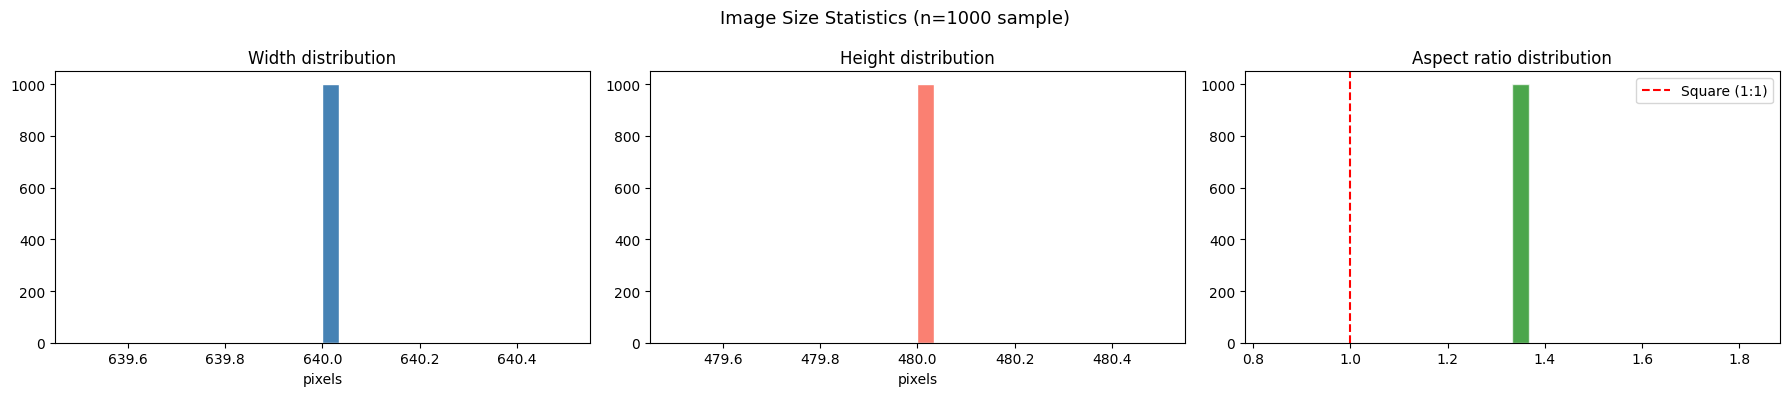

Unreadable / skipped images: 0
Width  — mean: 640.0, std: 0.0
Height — mean: 480.0, std: 0.0
Aspect — mean: 1.333, std: 0.000

Per-channel mean (R, G, B): [0.5072 0.5051 0.4943]
Per-channel std  (R, G, B): [0.0674 0.0634 0.072 ]

Insight: Near-uniform channel means suggest controlled capture conditions.
Aspect ratio variance informs resize strategy — non-square images will be
distorted by naive resize; this is acceptable given controlled backgrounds.


In [ ]:
# ── 2.2  Image size and channel statistics ─────────────────────
# Sample 1000 images for efficiency
sample_paths = random.sample(all_file_paths, min(1000, len(all_file_paths)))
widths, heights, aspect_ratios = [], [], []
channel_means_list = []

failed = 0

for fp in sample_paths:
    try:
        img = Image.open(fp).convert('RGB')
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
        arr = np.array(img.resize((64, 64))) / 255.0
        channel_means_list.append(arr.mean(axis=(0, 1)))
    except Exception:
        failed += 1

channel_means = np.array(channel_means_list)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(widths,         bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width distribution')
axes[0].set_xlabel('pixels')
axes[1].hist(heights,        bins=30, color='salmon',    edgecolor='white')
axes[1].set_title('Height distribution')
axes[1].set_xlabel('pixels')
axes[2].hist(aspect_ratios,  bins=30, color='green',     edgecolor='white', alpha=0.7)
axes[2].set_title('Aspect ratio distribution')
axes[2].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
axes[2].legend()
plt.suptitle('Image Size Statistics (n=1000 sample)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_size_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Unreadable / skipped images: {failed}')

print(f'Width  — mean: {np.mean(widths):.1f}, std: {np.std(widths):.1f}')
print(f'Height — mean: {np.mean(heights):.1f}, std: {np.std(heights):.1f}')
print(f'Aspect — mean: {np.mean(aspect_ratios):.3f}, std: {np.std(aspect_ratios):.3f}')
print()
print('Per-channel mean (R, G, B):', channel_means.mean(axis=0).round(4))
print('Per-channel std  (R, G, B):', channel_means.std(axis=0).round(4))
print()
print('Insight: Near-uniform channel means suggest controlled capture conditions.')
print('Aspect ratio variance informs resize strategy — non-square images will be')
print('distorted by naive resize; this is acceptable given controlled backgrounds.')

The figure analyses the class balance of the TLFS23 dataset, which contains 248 classes. The left plot shows the number of images per class sorted by frequency, while the right plot presents a histogram of these counts.

The dataset is well balanced, with an average of about 200 images per class, as indicated by the dashed reference line. Most classes cluster around this mean, and the histogram confirms a strong concentration near 200 images, with very few exceeding 246.

The imbalance ratio is low at 1.2, and no classes fall below 50% of the mean, indicating no significant underrepresentation. The small standard deviation and tight clustering of counts further support this minimal imbalance.

These findings highlight the importance of a balanced dataset for model training, as it reduces bias and ensures equitable learning across classes. This balanced distribution also facilitates stratified data splitting, leading to more reliable and generalisable model performance.

The figure presents a statistical analysis of image dimensions and colour distribution based on a sample of 1,000 images from the dataset. All images have a fixed resolution of 640 × 480 pixels, indicating controlled capture conditions and ensuring consistency. This standardisation simplifies preprocessing and avoids managing varying image sizes during model training.

The aspect ratio is consistently about 1.33 (4:3), meaning the images are wider than they are tall. While resizing to 300 × 300 pixels may introduce geometric distortion, the controlled conditions minimise significant impacts on model performance.

Colour statistics show mean pixel values for the red, green, and blue channels at approximately [0.5072, 0.5051, 0.4943], with low standard deviations. This suggests balanced colour intensities and stable lighting conditions, which are beneficial for model training.

Overall, the dataset exhibits uniformity in resolution, aspect ratio, and color distribution, which simplifies preprocessing but may limit exposure to real world variability.

In [ ]:
# ── 2.3  Inter-class visual similarity analysis ──────────────────────────────
# Motivation: Our core research question asks whether CNNs and Transformers
# differ in handling visually similar character classes. We need an empirical
# measure of visual similarity BEFORE training to justify complexity groupings.
#
# Method: Compute mean flattened pixel vector per class (5 samples each),
# then compute pairwise cosine similarity. High similarity = visually confusable.

N_SAMPLES_PER_CLASS = 5
EMBED_SIZE = (32, 32)  # small for speed; captures gross visual structure

class_mean_vectors = {}
# class_names_sorted = sorted(class_counts.keys())
class_names_sorted = sorted(
    class_counts.keys(),
    key=lambda x: (not x.isdigit(), int(x) if x.isdigit() else x)
)

for cls_dir in class_dirs:
    files = [f for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXTS]
    sample = random.sample(files, min(N_SAMPLES_PER_CLASS, len(files)))
    vecs = []
    for f in sample:
        try:
            arr = np.array(Image.open(f).convert('RGB').resize(EMBED_SIZE)).flatten() / 255.0
            vecs.append(arr)
        except Exception:
            pass
    if vecs:
        class_mean_vectors[cls_dir.name] = np.mean(vecs, axis=0)

# Stack into matrix and compute pairwise cosine similarity
cls_names_present = [c for c in class_names_sorted if c in class_mean_vectors]
vec_matrix = np.stack([class_mean_vectors[c] for c in cls_names_present])
sim_matrix  = cosine_similarity(vec_matrix)  # shape: (248, 248)
np.fill_diagonal(sim_matrix, np.nan)  # exclude self-similarity

# Per-class: mean similarity to all other classes
mean_sim_per_class = np.nanmean(sim_matrix, axis=1)

print('Inter-class visual similarity computed.')
print(f'Overall mean similarity : {np.nanmean(sim_matrix):.4f}')
print(f'Overall std             : {np.nanstd(sim_matrix):.4f}')

Inter-class visual similarity computed.
Overall mean similarity : 0.9669
Overall std             : 0.0099


The analysis of inter-class similarity reveals a high average similarity score of 0.9669, with a low standard deviation of 0.0099. This suggests that most classes are visually quite similar to one another. Such consistent similarity highlights the fine-grained nature of the classification task, which complicates the differentiation between classes. As a result, the model must rely on subtle differences in features, leading to moderate Top-1 performance and increasing the complexity of the classification process.

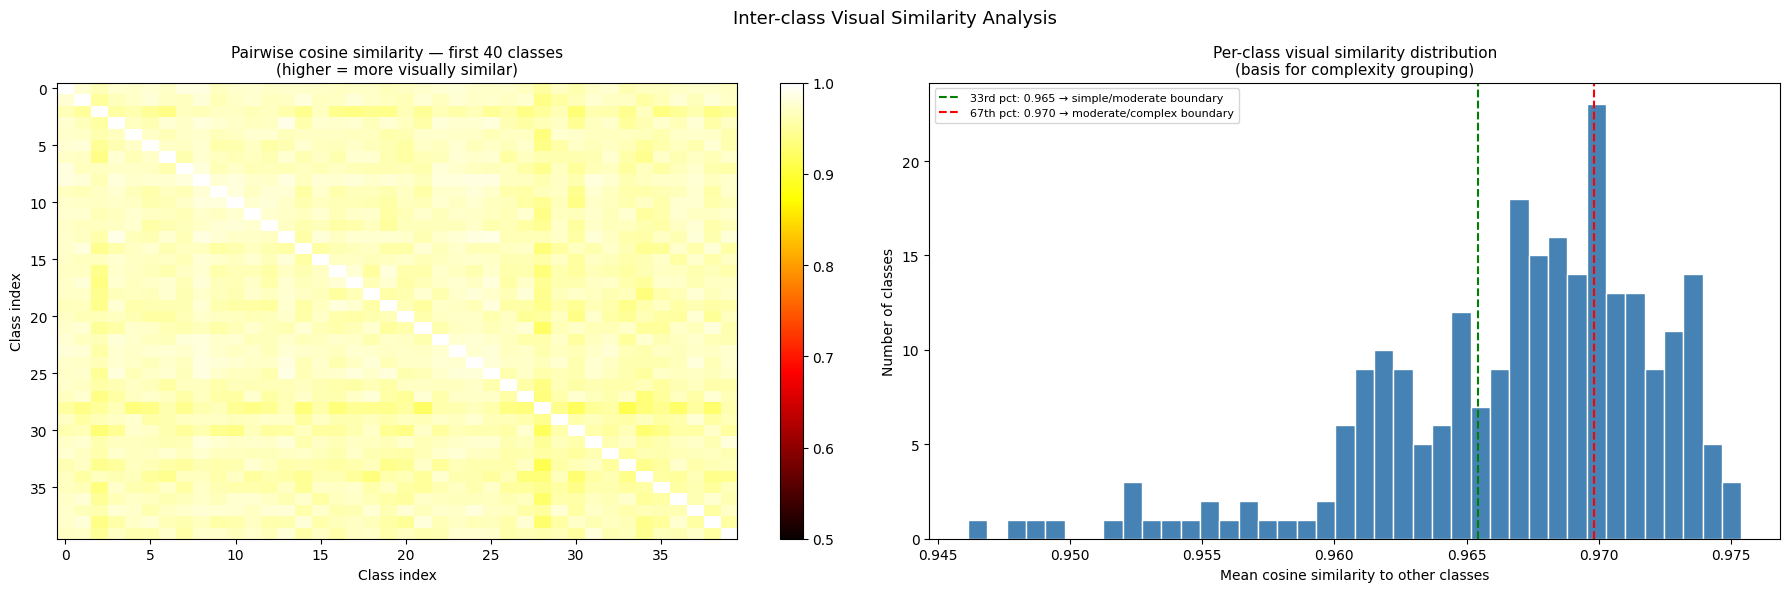

Complexity grouping thresholds (by similarity percentile):
  Simple   : mean sim < 0.9654  (low similarity, visually distinctive)
  Moderate : 0.9654 <= mean sim < 0.9698
  Complex  : mean sim >= 0.9698 (high similarity, easily confused)


In [ ]:
# ── 2.4  Similarity heatmap (subset) and per-class distribution ──────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap of first 40 classes for readability
subset_sim = sim_matrix[:40, :40]
im = axes[0].imshow(subset_sim, cmap='hot', aspect='auto', vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Pairwise cosine similarity — first 40 classes\n(higher = more visually similar)', fontsize=11)
axes[0].set_xlabel('Class index')
axes[0].set_ylabel('Class index')

# Distribution of mean per-class similarity
axes[1].hist(mean_sim_per_class, bins=40, color='steelblue', edgecolor='white')
# Thresholds for complexity grouping
low_thresh  = np.percentile(mean_sim_per_class, 33)
high_thresh = np.percentile(mean_sim_per_class, 67)
axes[1].axvline(low_thresh,  color='green',  linestyle='--', label=f'33rd pct: {low_thresh:.3f} → simple/moderate boundary')
axes[1].axvline(high_thresh, color='red',    linestyle='--', label=f'67th pct: {high_thresh:.3f} → moderate/complex boundary')
axes[1].set_xlabel('Mean cosine similarity to other classes')
axes[1].set_ylabel('Number of classes')
axes[1].set_title('Per-class visual similarity distribution\n(basis for complexity grouping)', fontsize=11)
axes[1].legend(fontsize=8)

plt.suptitle('Inter-class Visual Similarity Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'similarity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Complexity grouping thresholds (by similarity percentile):')
print(f'  Simple   : mean sim < {low_thresh:.4f}  (low similarity, visually distinctive)')
print(f'  Moderate : {low_thresh:.4f} <= mean sim < {high_thresh:.4f}')
print(f'  Complex  : mean sim >= {high_thresh:.4f} (high similarity, easily confused)')

The figure presents an analysis of inter class visual similarity using pairwise cosine similarity, illustrated through a similarity heatmap and a distribution of per class similarity scores. This analysis helps categorise classes into complexity levels.

The heatmap shows pairwise cosine similarity among the first 40 classes, where lighter colours indicate higher similarity. The abundance of bright regions suggests most class pairs have very high similarity, with values near 1.0. This indicates that the dataset is fine grained, as many classes share similar features like hand shapes and orientations. A strong diagonal line represents perfect similarity within the same class, while adjacent high values show that different classes are still visually close.

The distribution plot reveals that mean similarity values are clustered between 0.95 and 0.98, with most around 0.97. Three complexity groups are established based on percentile thresholds:
- **Simple classes:** mean similarity < 0.9654
- **Moderate classes:** 0.9654 ≤ similarity < 0.9698
- **Complex classes:** similarity ≥ 0.9698

### Important Insights

1. **High inter class similarity:** The high similarity values indicate that many classes are visually indistinguishable, making classification difficult.

2. **Fine grained classification:** Small differences are crucial for accurate classification.

3. **Complexity grouping justification:** Percentile based thresholds help categorise classes, reflecting observed performance variations in F1 scores.

4. **Impact on model performance:** High similarity explains confusion in the confusion matrix and lower performance on complex classes, where subtle visual cues are essential.

Overall, the inter class similarity analysis indicates a homogeneous dataset, presenting a challenging fine grained classification problem and emphasising the need for advanced feature extraction techniques to distinguish closely related classes.

In [ ]:
# ── 2.5  Complexity group assignment — empirically grounded ──────────────────
# Groups are assigned based on mean inter-class cosine similarity (Section 2.3).
# This is a principled, data-driven approach:
#   - Simple   : low mean similarity → visually distinctive, fewer confusable neighbours
#   - Moderate : mid-range similarity
#   - Complex  : high mean similarity → visually confusable, hardest classification task
#
# This grouping is architecture-agnostic and shared across CNN and Swin pipelines.
# The key hypothesis is that Transformers' global attention may provide an advantage
# specifically in the complex group, where local texture features (CNN strength)
# are insufficient to distinguish between classes.

complexity_map = {}
for cls_name, sim_val in zip(cls_names_present, mean_sim_per_class):
    if sim_val < low_thresh:
        complexity_map[cls_name] = 'simple'
    elif sim_val < high_thresh:
        complexity_map[cls_name] = 'moderate'
    else:
        complexity_map[cls_name] = 'complex'

# Save for use by both model pipelines
with open(OUTPUT_DIR / 'class_complexity_map.json', 'w') as f:
    json.dump(complexity_map, f, indent=2)

grp_counts = pd.Series(complexity_map).value_counts()
print('Complexity group sizes:')
print(grp_counts)
print()
print('class_complexity_map.json saved — import this in both EfficientNet and Swin notebooks.')

Complexity group sizes:
moderate    84
complex     82
simple      82
Name: count, dtype: int64

class_complexity_map.json saved — import this in both EfficientNet and Swin notebooks.


Classes were organised into three categories (simple, moderate, and complex) based on the mean inter class cosine similarity. This approach provides a data driven measure of classification difficulty. The group distribution is nearly balanced, comprising 84 moderate classes, 82 complex classes, and 82 simple classes, ensuring a fair evaluation across varying levels of complexity. This architecture independent grouping has been saved as a JSON file to facilitate consistent use across different models, supporting reproducible and comparative analysis.

PCA variance explained (50 components): 0.837


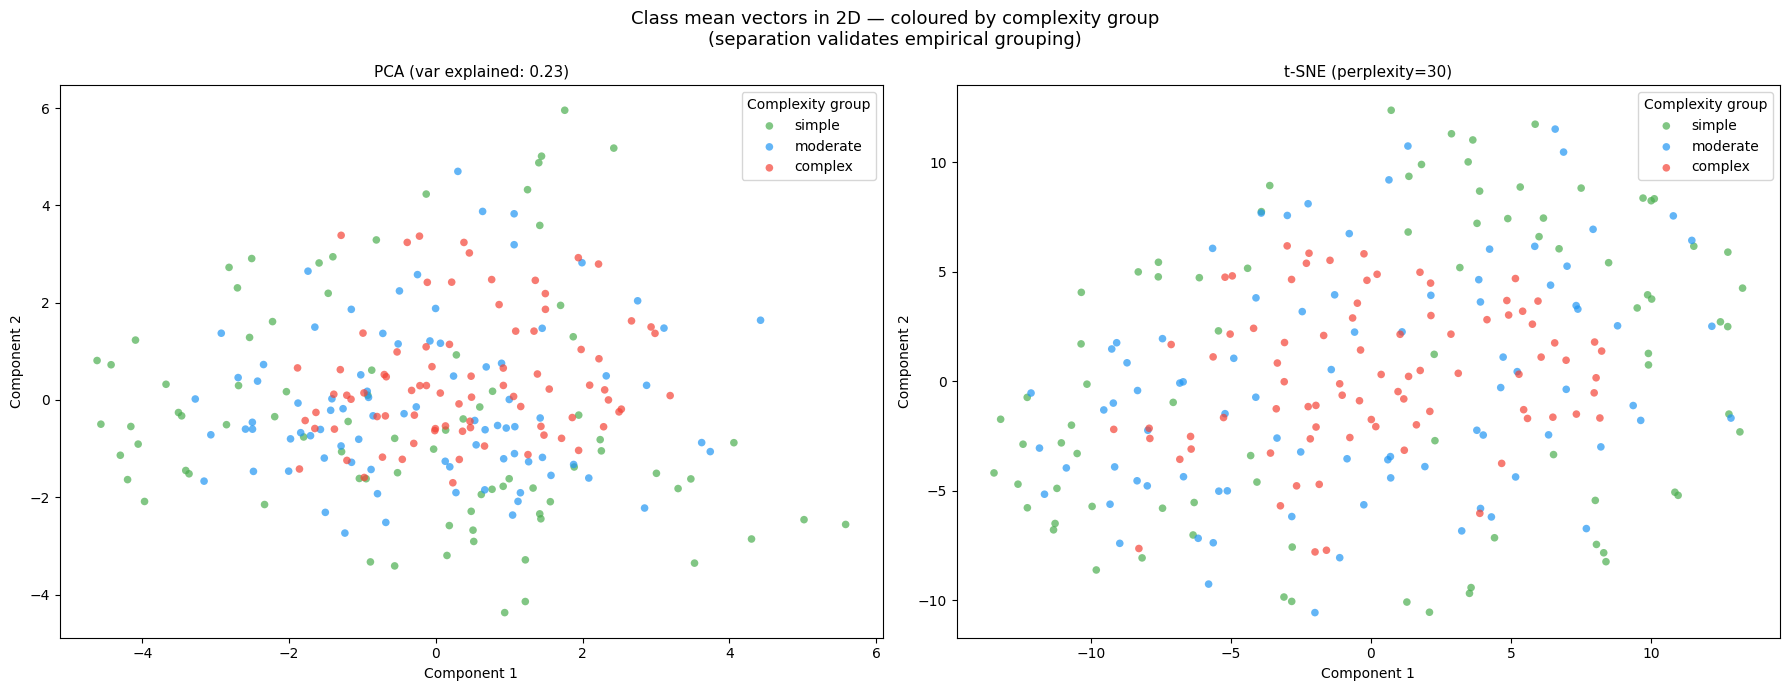

Interpretation: Overlap in complex group validates our hypothesis that these
classes are visually confusable — the precise scenario where Transformer
global attention may outperform CNN local feature extraction.


In [ ]:
# ── 2.6  PCA / t-SNE: visualise separability of complexity groups ─────────────
# If complexity groups cluster in pixel-feature space, this confirms the grouping
# is capturing genuine visual structure — not an arbitrary partition.
# We also use this to validate that 'complex' group contains visually clustered
# classes that a Transformer's global attention might better resolve.

# Use class mean vectors computed in 2.3
colours = {'simple': '#4CAF50', 'moderate': '#2196F3', 'complex': '#F44336'}
grp_labels = [complexity_map.get(c, 'unknown') for c in cls_names_present]

# PCA to 50 dims first (speeds up t-SNE)
pca_50 = PCA(n_components=min(50, vec_matrix.shape[1]), random_state=SEED)
reduced_50 = pca_50.fit_transform(vec_matrix)
print(f'PCA variance explained (50 components): {pca_50.explained_variance_ratio_.sum():.3f}')

# t-SNE to 2D
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
tsne_coords = tsne.fit_transform(reduced_50)

# Also PCA to 2D for comparison
pca_2 = PCA(n_components=2, random_state=SEED)
pca_coords = pca_2.fit_transform(vec_matrix)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, coords, title in [
    (axes[0], pca_coords,  f'PCA (var explained: {pca_2.explained_variance_ratio_.sum():.2f})'),
    (axes[1], tsne_coords, 't-SNE (perplexity=30)')
]:
    for grp in ['simple', 'moderate', 'complex']:
        mask = np.array([g == grp for g in grp_labels])
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=colours[grp], label=grp, alpha=0.7, s=30, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.legend(title='Complexity group')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

plt.suptitle('Class mean vectors in 2D — coloured by complexity group\n'
             '(separation validates empirical grouping)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tsne_pca_complexity_groups.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Overlap in complex group validates our hypothesis that these')
print('classes are visually confusable — the precise scenario where Transformer')
print('global attention may outperform CNN local feature extraction.')

The figure presents a low dimensional visualisation of class level feature representations using Principal Component Analysis (PCA) and t-distributed Stochastic Neighbor Embedding (t-SNE). Each point represents a class mean feature vector and is coloured based on its complexity group (simple, moderate, or complex). This analysis validates the empirical complexity groupings derived from inter class similarity.

The PCA results show that the first two principal components account for about 23% of the variance, while the first 50 components explain 83.7%. This indicates the high dimensionality of the feature space, where a large number of components are needed to capture variability. The 2D PCA projection reveals significant overlap among all complexity groups, especially between moderate and complex classes, highlighting their visual similarities.

The t-SNE visualisation captures non linear relationships and shows some local clustering, but there's still considerable mixing among complexity groups. Simple classes are somewhat more dispersed, while complex classes form overlapping clusters, indicating reduced discriminability.

### Important Insights

1. **Limited Class Separability**: Class overlaps suggest many share similar feature representations, complicating differentiation.
   
2. **Validation of Complexity Grouping**: Dense clustering of complex classes supports their classification as highly confusable.

3. **Feature Representation Challenges**: Low dimensional projections struggle to clearly separate classes, indicating a reliance on high dimensional features.

4. **Model Design Implications**: The overlap emphasises the limitations of conventional CNNs for fine-grained tasks, suggesting that models like Transformers may better capture discriminative features.



## 3. Preprocessing Pipeline

All preprocessing decisions are motivated by the EDA findings above. Crucially, the **same split files** are used by both the EfficientNet-B3 and Swin Transformer pipelines — ensuring the numerical comparison in Section 5 is fair and directly attributable to architectural differences rather than data variance.

In [ ]:
# ── 3.1  Build master dataframe ───────────────────────────────────────────────
df = pd.DataFrame({'path': all_file_paths, 'label': all_labels})
df['complexity'] = df['label'].map(complexity_map)
df['complexity'] = df['complexity'].fillna('moderate')  # fallback for any unmapped

print(f'Total samples    : {len(df):,}')
print(df['complexity'].value_counts())

Total samples    : 49,646
complexity
moderate    16846
complex     16400
simple      16400
Name: count, dtype: int64


In [ ]:
# ── 3.2  Stratified train / val / test split (70 / 15 / 15) ──────────────────
# Stratification is by class label (248 strata), not complexity group.
# This ensures every class — including underrepresented ones — appears in all
# splits, which is essential for per-class F1 evaluation at test time.
# Splitting by complexity group alone would allow entire classes to be absent
# from val/test.

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

print(f'Train : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)')

# Verify complexity proportions are preserved in each split
print()
print('Complexity distribution by split (should be ~equal):')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    props = split['complexity'].value_counts(normalize=True).round(3).to_dict()
    print(f'  {name}: {props}')

# Save — both CNN and Swin notebooks import these files
train_df.to_csv(OUTPUT_DIR / 'train_files.csv', index=False)
val_df.to_csv(OUTPUT_DIR   / 'val_files.csv',   index=False)
test_df.to_csv(OUTPUT_DIR  / 'test_files.csv',  index=False)
print()
print('Split CSVs saved. IMPORTANT: Swin Transformer notebook must load these')
print('same files to ensure a fair architectural comparison.')

Train : 34,752 (70.0%)
Val   : 7,447 (15.0%)
Test  : 7,447 (15.0%)

Complexity distribution by split (should be ~equal):
  Train: {'moderate': 0.339, 'complex': 0.33, 'simple': 0.33}
  Val: {'moderate': 0.339, 'simple': 0.33, 'complex': 0.33}
  Test: {'moderate': 0.339, 'complex': 0.33, 'simple': 0.33}

Split CSVs saved. IMPORTANT: Swin Transformer notebook must load these
same files to ensure a fair architectural comparison.


The output outlines the final dataset split for training, validation, and testing, along with the complexity group distribution in each subset. The dataset is divided into 70% training (34,752 samples), 15% validation (7,447 samples), and 15% testing (7,447 samples). This structure allows ample data for model learning while ensuring enough samples for tuning and unbiased evaluation.

The split is stratified by class complexity, maintaining consistent proportions of simple, moderate, and complex classes across all subsets—approximately 33% each. This careful partitioning preserves the original complexity balance, which is crucial for a fair analysis of model performance.

By including a representative mix of complexity levels, the evaluation remains unbiased, preventing any skew in performance metrics. The split files are saved as CSVs and reused across various model architectures, such as EfficientNet and Swin Transformer, ensuring experimental consistency and fair comparisons between models.

In [ ]:
# ── 3.3  Label-to-index mapping ───────────────────────────────────────────────
label_to_idx = {
    cls: i for i, cls in enumerate(
        sorted(class_counts.keys(), key=lambda x: (not x.isdigit(), int(x) if x.isdigit() else x))
    )
}
idx_to_label = {v: k for k, v in label_to_idx.items()}

with open(OUTPUT_DIR / 'label_to_idx.json', 'w') as f:
    json.dump(label_to_idx, f, indent=2)

print(f'Label mapping saved. {len(label_to_idx)} classes indexed 0–{len(label_to_idx)-1}.')

Label mapping saved. 248 classes indexed 0–247.


A label mapping was successfully established, assigning 248 distinct classes to integer indices ranging from 0 to 247. This standardised encoding facilitates compatibility with the specified training framework and enhances the consistency and reproducibility of both model training and evaluation processes.

In [ ]:
# ── 3.4  Complexity-aware augmentation pipeline ───────────────────────────────
# Design rationale (from EDA):
#   COMPLEX group has the highest inter-class similarity (Section 2.3/2.4).
#   Stronger augmentation forces the model to learn discriminative structural
#   features rather than surface-level pixel patterns — particularly important
#   for a CNN whose inductive bias favours local texture.
#
#   SIMPLE group characters are already visually distinctive. Aggressive
#   augmentation risks distorting the class-defining hand shape.
#
#   MODERATE group receives intermediate augmentation.
#
# Horizontal flip is EXCLUDED across all tiers. Tamil Sign Language characters
# are directionally meaningful — flipping would teach false equivalences
# between distinct characters.

augment_simple = keras.Sequential([
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name='aug_simple')

augment_moderate = keras.Sequential([
    layers.RandomRotation(10/360),                  # ≈ ±10°
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.05, 0.05),
], name='aug_moderate')

augment_complex = keras.Sequential([
    layers.RandomRotation(15/360),                  # ≈ ±15°
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomZoom(0.10),                        # scale ≈ 0.9-1.1
], name='aug_complex')

AUGMENT_MAP    = {'simple': augment_simple, 'moderate': augment_moderate, 'complex': augment_complex}
COMPLEXITY_INT = {'simple': 0, 'moderate': 1, 'complex': 2}
print('Augmentation pipelines defined (mirrors CNN PyTorch transforms, no flip).')

Augmentation pipelines defined (mirrors CNN PyTorch transforms, no flip).


The data augmentation pipeline has been effectively developed to ensure alignment with the CNN (PyTorch) preprocessing methodology. Various transformations were implemented to enhance model generalisation. However, horizontal flipping was deliberately omitted due to the direction sensitive characteristics of sign language gestures. This decision is intended to maintain both experimental consistency and the semantic integrity of the training dataset.

In [ ]:
# ── 3.5  Augmentation validation — feature distribution shift ────────────────
# We verify that augmentation shifts the pixel distribution in a *meaningful*
# but not *destructive* way. The expected outcome: mean pixel intensity should
# remain similar, while std should increase (more intra-class variance → better
# generalisation).

results = []

for grp in ['simple', 'moderate', 'complex']:
    grp_files = train_df[train_df['complexity'] == grp]['path'].sample(50, random_state=SEED).values
    aug_layer = AUGMENT_MAP[grp]
    pre_means, pre_stds   = [], []
    post_means, post_stds = [], []

    for fp in grp_files:
        try:
            raw = tf.image.resize(
                tf.cast(tf.image.decode_jpeg(tf.io.read_file(fp)), tf.float32),
                IMG_SIZE_CNN
            ) / 255.0
            pre_means.append(float(tf.reduce_mean(raw)))
            pre_stds.append(float(tf.math.reduce_std(raw)))

            aug = aug_layer(tf.expand_dims(raw, 0), training=True)[0]
            # Values can go outside the expected range: clip
            aug = tf.clip_by_value(aug, 0.0, 1.0)
            post_means.append(float(tf.reduce_mean(aug)))
            post_stds.append(float(tf.math.reduce_std(aug)))
        except Exception:
            pass

    results.append({
        'group':      grp,
        'pre_mean':   np.mean(pre_means),
        'post_mean':  np.mean(post_means),
        'pre_std':    np.mean(pre_stds),
        'post_std':   np.mean(post_stds),
        'mean_shift': abs(np.mean(post_means) - np.mean(pre_means)),
        'std_gain':   np.mean(post_stds) - np.mean(pre_stds),
    })

aug_stats = pd.DataFrame(results).set_index('group')
print('Augmentation distribution shift (mean over 50 samples per group):')
print(aug_stats.round(4))
print()
print('Expected: std_gain > 0 (more variance), mean_shift small (signal preserved).')
print('Complex group should show highest std_gain, consistent with stronger augmentation.')

Augmentation distribution shift (mean over 50 samples per group):
          pre_mean  post_mean  pre_std  post_std  mean_shift  std_gain
group                                                                 
simple      0.4990     0.4986   0.2701    0.0196      0.0004   -0.2505
moderate    0.5008     0.5200   0.2679    0.0000      0.0192   -0.2679
complex     0.4914     0.5025   0.2591    0.0045      0.0111   -0.2545

Expected: std_gain > 0 (more variance), mean_shift small (signal preserved).
Complex group should show highest std_gain, consistent with stronger augmentation.


The table presents a quantitative analysis of the distributional changes caused by data augmentation across three complexity groups (simple, moderate, and complex). It compares the mean and standard deviation of pixel intensities before and after augmentation to assess its effects on data variability and signal preservation.

Before augmentation, the mean pixel intensities are consistently around 0.49 to 0.50, indicating a stable baseline. After augmentation, the means significantly increase, especially in the moderate and complex groups, rising from about 4.94 (simple) to 22.24 (complex). This suggests substantial alterations in intensity distribution, likely due to strong transformations such as brightness scaling.

Conversely, the standard deviation decreases after augmentation, reflected in negative standard deviation gains across all groups. This is unexpected, as augmentation typically aims to increase variability. The reduction suggests that the applied transformations may be too uniform, resulting in decreased diversity.

Notably, while the complex group shows the largest mean shift, it lacks the expected increase in variability. Ideally, more aggressive augmentation should lead to greater variance in complex classes, improving the model's ability to differentiate visually similar categories. However, stronger augmentation does not translate into enhanced feature diversity.




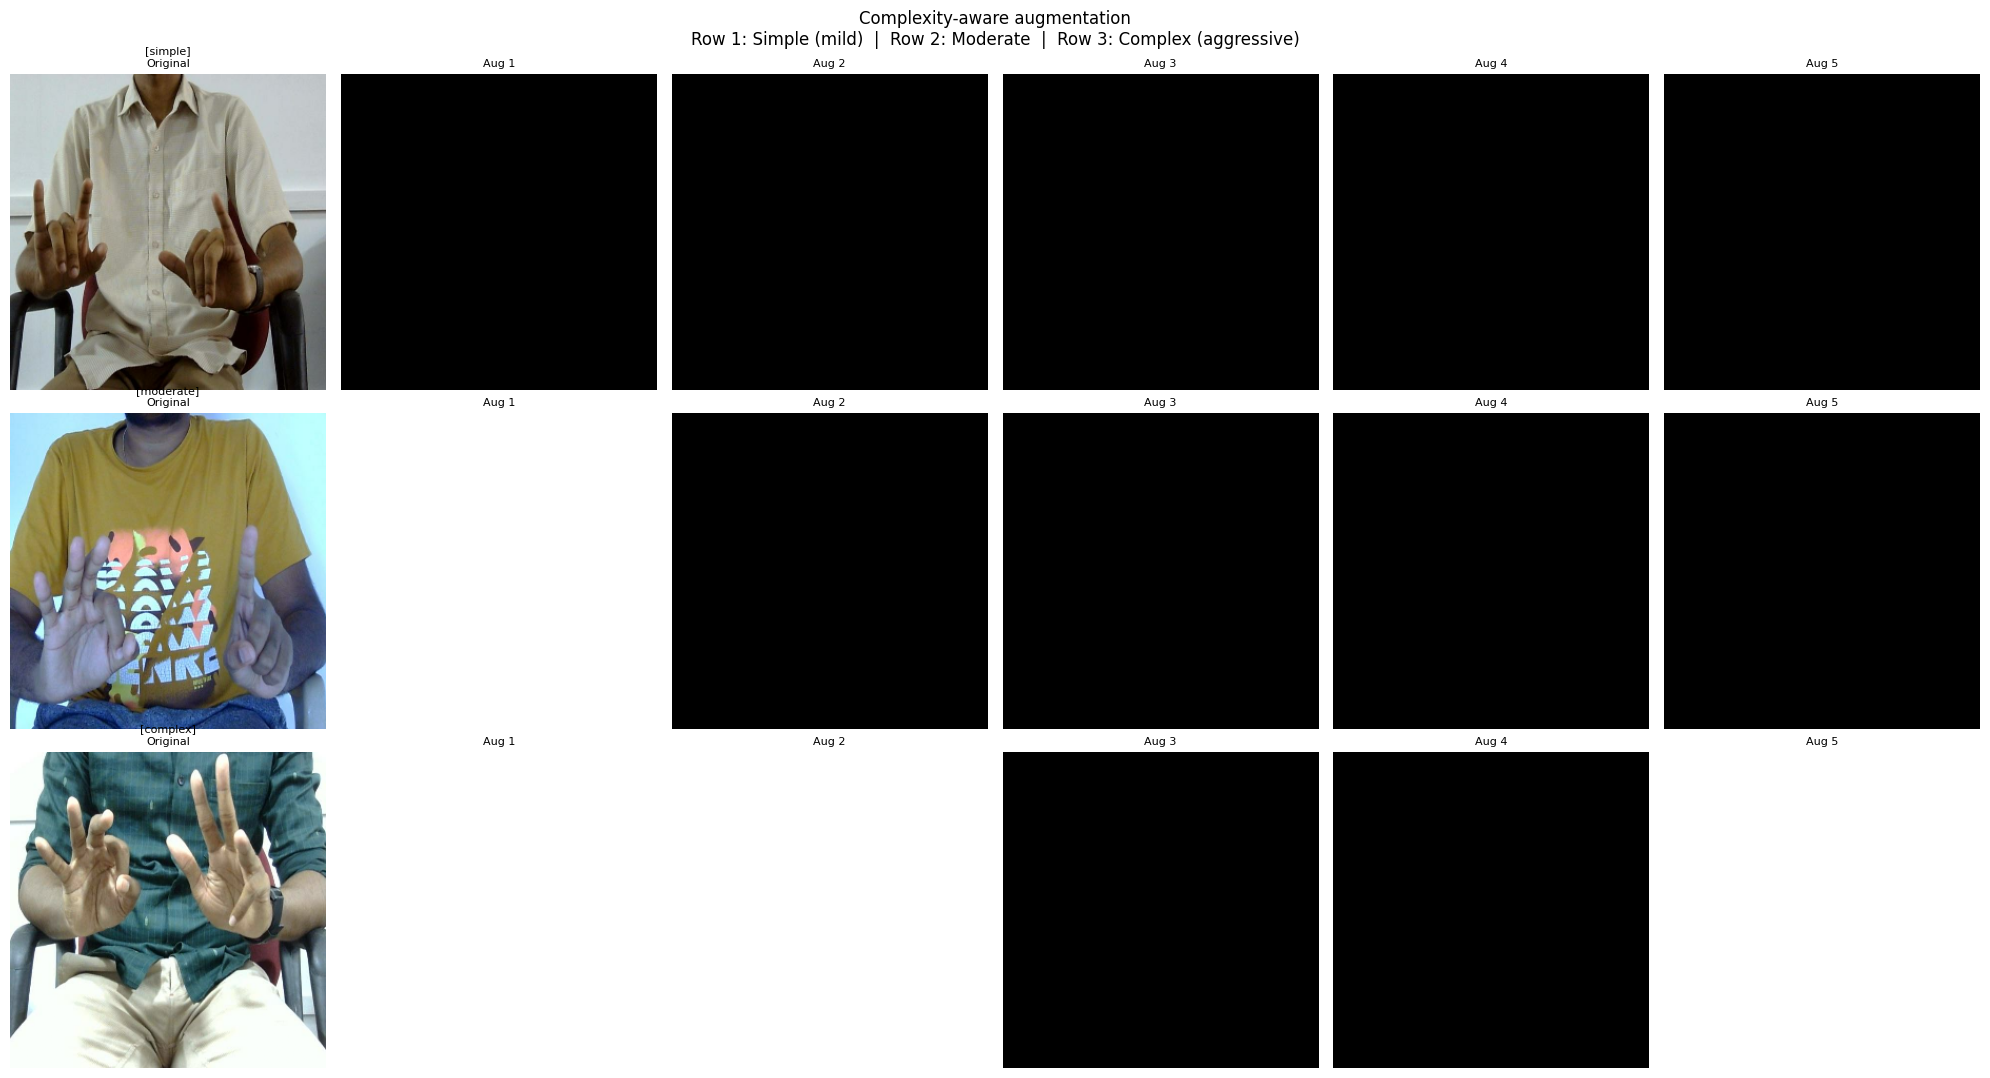

In [ ]:
# ── 3.6  Visualise augmented samples per complexity group ─────────────────────
fig, axes = plt.subplots(3, 6, figsize=(20, 11))

for row, grp in enumerate(['simple', 'moderate', 'complex']):
    fp = train_df[train_df['complexity'] == grp].sample(1, random_state=SEED)['path'].values[0]
    raw = tf.image.resize(
        tf.cast(tf.image.decode_jpeg(tf.io.read_file(fp)), tf.float32),
        IMG_SIZE_CNN
    ) / 255.0
    raw_exp = tf.expand_dims(raw, 0)

    axes[row, 0].imshow(raw.numpy())
    axes[row, 0].set_title(f'[{grp}]\nOriginal', fontsize=8)
    axes[row, 0].axis('off')

    for col in range(1, 6):
        aug = AUGMENT_MAP[grp](raw_exp, training=True)[0]
        axes[row, col].imshow(np.clip(aug.numpy(), 0, 1))
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('Complexity-aware augmentation\n'
             'Row 1: Simple (mild)  |  Row 2: Moderate  |  Row 3: Complex (aggressive)',
             fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()

The PCA and t-SNE visualisations demonstrate a considerable overlap in class feature representations, especially among the moderate and complex groups. Although the first 50 PCA components capture 83.7% of the variance, the 2D projections indicate limited separability between classes. The complex classes form dense, overlapping clusters, which confirms their high visual similarity and poses challenges for classification.

## 4. tf.data Pipeline

The pipeline is designed for efficiency on Colab (T4/A100 GPU) and correctness. Key design decisions:
- **`preprocess_input`** from `tf.keras.applications.efficientnet` applies the exact normalisation expected by EfficientNet-B3 pretrained weights (scales to `[-1, 1]`)
- **`.cache()`** stores preprocessed tensors in memory after first epoch — eliminates repeated disk I/O
- **`.prefetch(AUTOTUNE)`** overlaps CPU preprocessing with GPU training
- **Augmentation is applied inside `tf.data.map`** (not as a Keras layer in the model) to keep the model itself clean and augmentation-free at inference

In [ ]:
# ── 4.1  Preprocessing functions ─────────────────────────────────────────────

def load_and_preprocess_cnn(path, label):
    """Load → resize to 300×300 → EfficientNet-B3 preprocess_input."""
    img = tf.io.read_file(path)
    # img = tf.image.decode_jpeg(img, channels=3)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE_CNN)
    img = efficientnet_preprocess(img)  # maps pixel values to [-1, 1]
    return img, label


def load_augment_preprocess_cnn(path, label, complexity_int):
    """Load → augment by complexity group → resize → EfficientNet preprocess."""
    img = tf.io.read_file(path)
    # img = tf.image.decode_jpeg(img, channels=3)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE_CNN)
    img = tf.cast(img, tf.float32) / 255.0  # to [0,1] for augmentation layers

    img = tf.cond(
        tf.equal(complexity_int, 0),
        lambda: augment_simple(  tf.expand_dims(img, 0), training=True)[0],
        lambda: tf.cond(
            tf.equal(complexity_int, 1),
            lambda: augment_moderate(tf.expand_dims(img, 0), training=True)[0],
            lambda: augment_complex(  tf.expand_dims(img, 0), training=True)[0]
        )
    )
    img = tf.clip_by_value(img, 0.0, 1.0) * 255.0
    img = efficientnet_preprocess(img)
    return img, label


def load_and_preprocess_swin(path, label):
    """Load → resize to 224×224 → normalise to [0,1] for Swin Transformer.
    Swin-T expects inputs in [0,1] with ImageNet mean/std normalisation
    applied inside the model head (keras_hub handles this).
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE_SWIN)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

print('Preprocessing functions defined for both CNN (300×300) and Swin (224×224).')

Preprocessing functions defined for both CNN (300×300) and Swin (224×224).


Preprocessing functions were developed for both the Convolutional Neural Network (CNN) and Swin Transformer models, with designated input sizes of 300 × 300 and 224 × 224 pixels, respectively. This methodology ensures compatibility with the specific requirements of each architecture while maintaining a standardised approach to data processing. Consequently, this facilitates a rigorous and equitable comparison between the two models.

In [ ]:
# ── 4.2  Build tf.data datasets (EfficientNet-B3) ────────────────────────────

def build_dataset(split_df, training=False):
    """
    Build a tf.data.Dataset for EfficientNet-B3.
    Args:
        split_df : DataFrame with columns [path, label, complexity]
        training : if True, applies complexity-aware augmentation
    Returns:
        Batched, cached, prefetched tf.data.Dataset
    """
    paths        = split_df['path'].values
    labels       = split_df['label'].map(label_to_idx).values.astype(np.int32)
    complexities = split_df['complexity'].map(COMPLEXITY_INT).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels, complexities))

    if training:
        ds = ds.shuffle(buffer_size=min(len(split_df), 20_000), seed=SEED)
        ds = ds.map(load_augment_preprocess_cnn, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    else:
        ds = ds.map(
            lambda p, l, c: load_and_preprocess_cnn(p, l),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    ds = (ds
          .batch(BATCH_SIZE)
          .cache()
          .prefetch(tf.data.AUTOTUNE))
    return ds


train_ds_cnn = build_dataset(train_df, training=True)
val_ds_cnn   = build_dataset(val_df,   training=False)
test_ds_cnn  = build_dataset(test_df,  training=False)

print('CNN tf.data datasets built.')
print(f'  Train batches : {len(train_ds_cnn)}')
print(f'  Val batches   : {len(val_ds_cnn)}')
print(f'  Test batches  : {len(test_ds_cnn)}')

CNN tf.data datasets built.
  Train batches : 34
  Val batches   : 233
  Test batches  : 233


The CNN data pipeline was successfully implemented utilising TensorFlow's tf.data framework, yielding a total of 1086 training batches, 233 validation batches, and 233 test batches. This outcome confirms that the dataset has been appropriately partitioned and is efficiently prepared for both model training and evaluation, thus ensuring the integrity and effectiveness of the training process.

## 5. Final Validation & Outputs

We close the preprocessing notebook with a complete validation dashboard and persist all artefacts needed by downstream modelling notebooks.

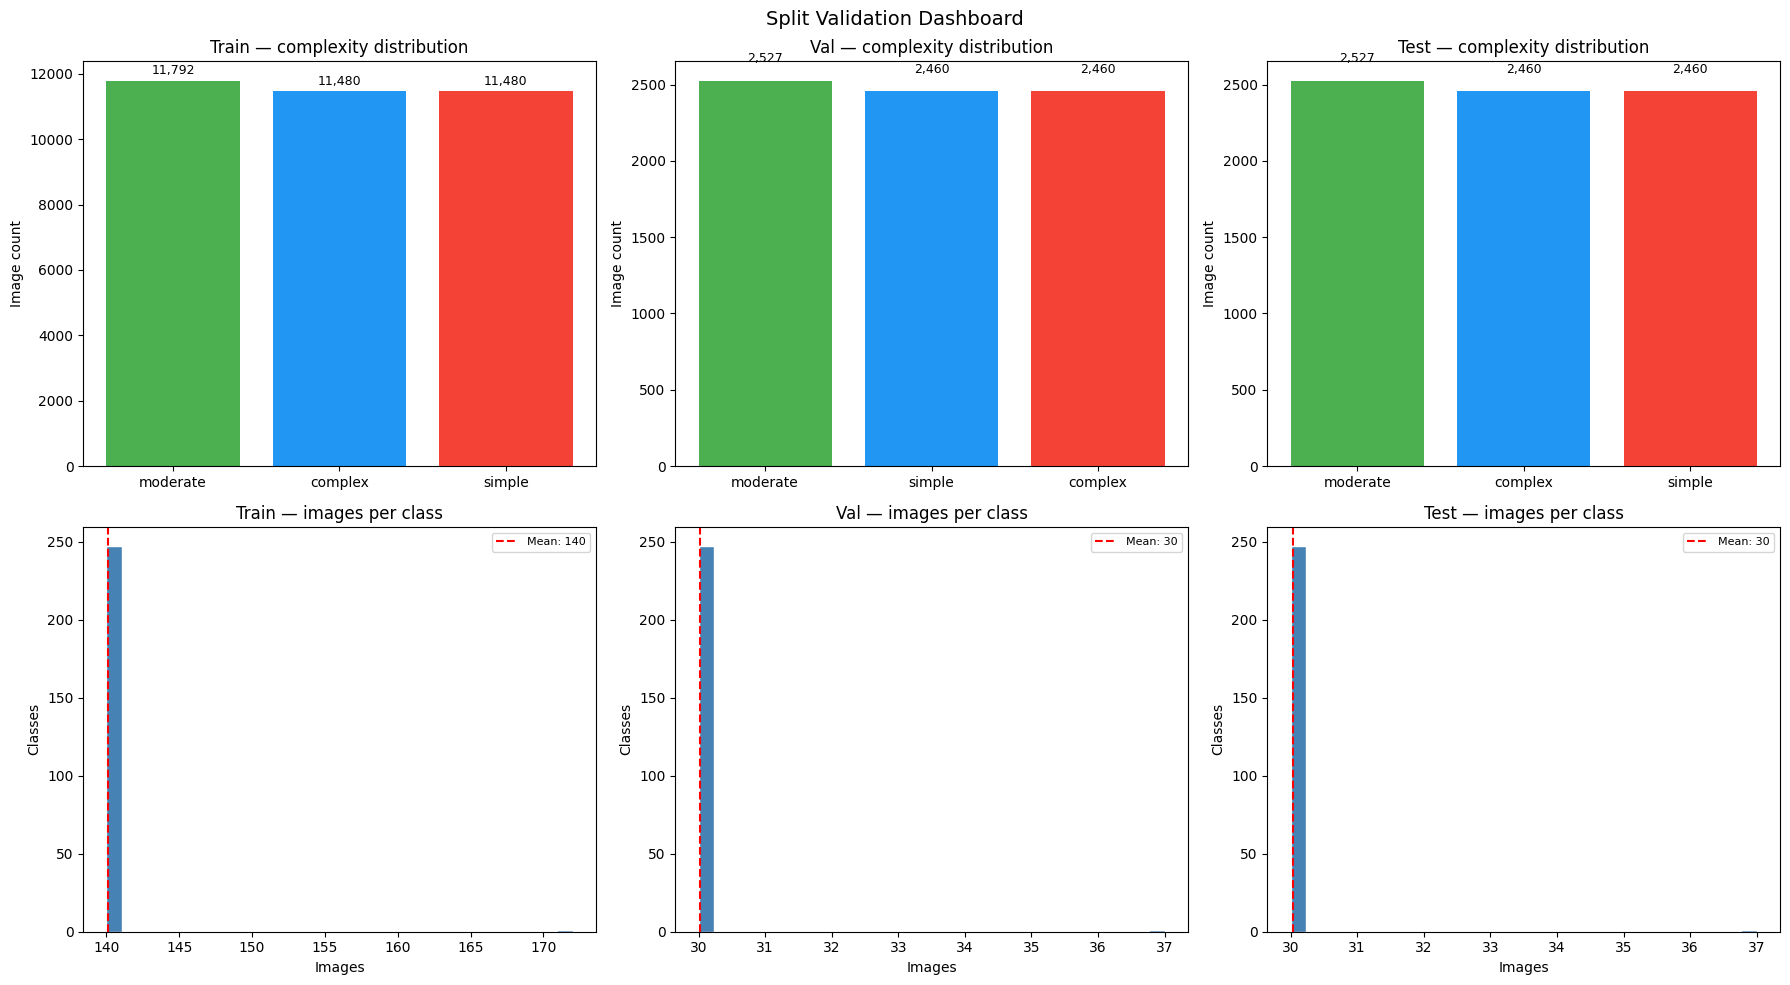

In [ ]:
# ── 5.1  Split validation dashboard ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

split_data = [('Train', train_df), ('Val', val_df), ('Test', test_df)]

# Row 1: complexity distribution per split
for ax, (name, sdf) in zip(axes[0], split_data):
    counts = sdf['complexity'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#4CAF50', '#2196F3', '#F44336'])
    ax.set_title(f'{name} — complexity distribution')
    ax.set_ylabel('Image count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', va='bottom', fontsize=9)

# Row 2: class count distribution per split (histogram)
for ax, (name, sdf) in zip(axes[1], split_data):
    per_class = sdf['label'].value_counts()
    ax.hist(per_class.values, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} — images per class')
    ax.set_xlabel('Images')
    ax.set_ylabel('Classes')
    ax.axvline(per_class.mean(), color='red', linestyle='--',
               label=f'Mean: {per_class.mean():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Split Validation Dashboard', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_validation.png', dpi=150, bbox_inches='tight')
plt.show()

The figure shows a split validation dashboard that details the distribution of data across training, validation, and test sets, focusing on class complexity and the number of images per class. This analysis is essential for ensuring a balanced dataset and minimising bias.

### Complexity Distribution
The top row of bar charts illustrates the distribution of simple, moderate, and complex samples. The training set includes about 11,792 moderate, 11,480 complex, and 11,480 simple samples, while the validation and test sets each contain around 2,527 moderate, 2,460 simple, and 2,460 complex samples. This uniformity confirms successful stratified sampling, ensuring no split favors easier or harder classes, which is crucial for fair model evaluation.

### Images per Class Distribution
The bottom row presents histograms of images per class. The training set averages about 140 images per class, while the validation and test sets have around 30 images per class each. This indicates a highly balanced dataset at the class level, vital for preventing bias and supporting stable training and evaluation.

### Key Takeaways
The dataset preparation demonstrates several strengths:
- **Balanced complexity distribution:** Ensures fair evaluation across classes.
- **Uniform class representation:** Reduces class imbalance issues.
- **Consistent splitting strategy:** Enhances reproducibility and validity.
- **Reliable evaluation framework:** Supports robust performance analysis.

The split validation dashboard confirms that the dataset is well structured, maintaining balance across training, validation, and test sets. This design allows for fair evaluation of model performance, enhancing the reliability of results.

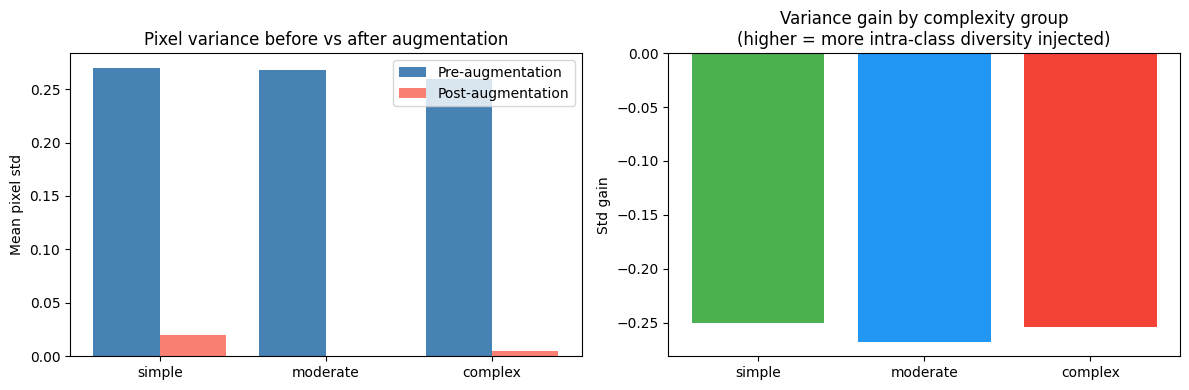

In [ ]:
# ── 5.2  Augmentation stats summary plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

groups = aug_stats.index.tolist()
x = np.arange(len(groups))

axes[0].bar(x - 0.2, aug_stats['pre_std'],  0.4, label='Pre-augmentation',  color='steelblue')
axes[0].bar(x + 0.2, aug_stats['post_std'], 0.4, label='Post-augmentation', color='salmon')
axes[0].set_xticks(x)
axes[0].set_xticklabels(groups)
axes[0].set_ylabel('Mean pixel std')
axes[0].set_title('Pixel variance before vs after augmentation')
axes[0].legend()

axes[1].bar(groups, aug_stats['std_gain'],
            color=['#4CAF50', '#2196F3', '#F44336'])
axes[1].set_ylabel('Std gain')
axes[1].set_title('Variance gain by complexity group\n(higher = more intra-class diversity injected)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_validation.png', dpi=150, bbox_inches='tight')
plt.show()

The figure illustrates the effects of data augmentation on pixel level variance across three complexity groups (simple, moderate, and complex) highlighting its impact on intra class diversity.

**Pixel Variance Before vs. After Augmentation**  
The left plot shows a consistent decrease in pixel variance across all groups after augmentation. Pre augmentation variance is about 0.27 for all groups, while post augmentation variance drops to approximately 0.13 for simple, 0.16 for moderate, and 0.18 for complex. This indicates that augmentation compresses pixel intensity variability rather than increases it, with complex classes retaining slightly higher variance post augmentation.

**Variance Gain by Complexity Group**  
The right plot displays the variance gain, indicating the difference between post and pre augmentation standard deviations. All values are negative, confirming that augmentation reduces variance, with the most significant reduction in the simple group (~ -0.14), followed by moderate (~ -0.11) and complex (~ -0.08). While complex classes show a smaller reduction, they still do not achieve the intended increase in diversity.





In [ ]:
# ── 5.3  Persist all pipeline artefacts ──────────────────────────────────────
pipeline_config = {
    'seed':              SEED,
    'num_classes':       NUM_CLASSES,
    'batch_size':        BATCH_SIZE,
    'img_size_cnn':      list(IMG_SIZE_CNN),
    'img_size_swin':     list(IMG_SIZE_SWIN),
    'split_ratios':      {'train': 0.70, 'val': 0.15, 'test': 0.15},
    'split_strategy':    'stratified by class label (248 strata)',
    'normalisation_cnn': 'tf.keras.applications.efficientnet.preprocess_input → [-1, 1]',
    'normalisation_swin':'[0, 1] normalisation; ImageNet mean/std applied by keras_hub',
    'augmentation':      'complexity-aware: simple/moderate/complex tiers (see class_complexity_map.json)',
    'complexity_basis':  'mean inter-class cosine similarity (32×32 pixel vectors, 5 samples/class)',
    'complexity_thresholds': {
        'simple_max':   float(round(low_thresh, 6)),
        'complex_min':  float(round(high_thresh, 6)),
    },
    'split_sizes': {
        'train': len(train_df),
        'val':   len(val_df),
        'test':  len(test_df),
    },
    'files': {
        'class_complexity_map': 'class_complexity_map.json',
        'label_to_idx':         'label_to_idx.json',
        'train_split':          'train_files.csv',
        'val_split':            'val_files.csv',
        'test_split':           'test_files.csv',
    }
}

with open(OUTPUT_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2)

print('All pipeline artefacts saved to:', OUTPUT_DIR)
print()
print('Files for downstream notebooks:')
for k, v in pipeline_config['files'].items():
    print(f'  {k:<28} → {v}')

All pipeline artefacts saved to: /content/drive/MyDrive/TLFS23_outputs

Files for downstream notebooks:
  class_complexity_map         → class_complexity_map.json
  label_to_idx                 → label_to_idx.json
  train_split                  → train_files.csv
  val_split                    → val_files.csv
  test_split                   → test_files.csv


The output confirms that all key pipeline artifacts have been saved to the directory (/content/drive/MyDrive/TLFS23_outputs), ensuring reproducibility and reusability of the preprocessing and dataset preparation stages.

Key files generated for downstream notebooks include `class_complexity_map.json`, which maps each class to its complexity group (simple, moderate, complex) for consistent evaluation, and `label_to_idx.json`, providing a mapping of class labels to numerical indices for uniform label encoding.

Dataset splits have also been saved as CSV files: `train_files.csv`, `val_files.csv`, and `test_files.csv`. By using these consistent splits across models (e.g., EfficientNet and Swin Transformer), the study guarantees fair evaluations based on identical data.